In [33]:
import torch
from torch import Tensor
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('png', 'pdf')

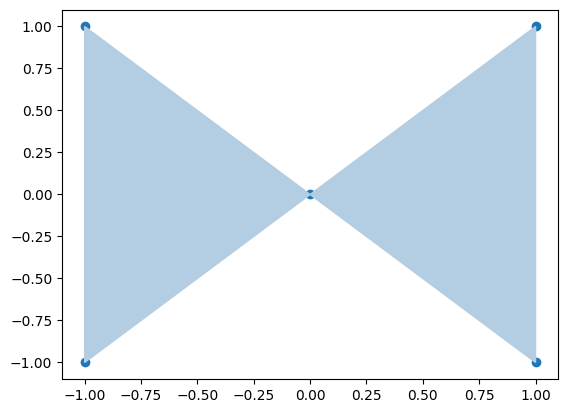

In [34]:
dots = torch.tensor([[-1, 1], [-1, -1], [0, 0], [1, 1], [1, -1]])
plt.figure()
plt.scatter(dots[:, 0], dots[:, 1])
t1 = plt.Polygon([[-1, 1], [-1, -1], [0, 0]], color = '#b3cde3')
plt.gca().add_patch(t1)

t2 = plt.Polygon(dots[2:5,:], color='#b3cde3')
plt.gca().add_patch(t2)
plt.show()

In [35]:
# Build a grid of equally-spaced points, plus a column for the bias
grid_range = torch.linspace(-2, 2, 50)
grid_x, grid_y = torch.meshgrid(grid_range, grid_range, indexing='ij')
data = torch.stack([torch.ones(50**2), grid_x.flatten(), grid_y.flatten()]).T
print(data.shape)
print(data[:10])

torch.Size([2500, 3])
tensor([[ 1.0000, -2.0000, -2.0000],
        [ 1.0000, -2.0000, -1.9184],
        [ 1.0000, -2.0000, -1.8367],
        [ 1.0000, -2.0000, -1.7551],
        [ 1.0000, -2.0000, -1.6735],
        [ 1.0000, -2.0000, -1.5918],
        [ 1.0000, -2.0000, -1.5102],
        [ 1.0000, -2.0000, -1.4286],
        [ 1.0000, -2.0000, -1.3469],
        [ 1.0000, -2.0000, -1.2653]])


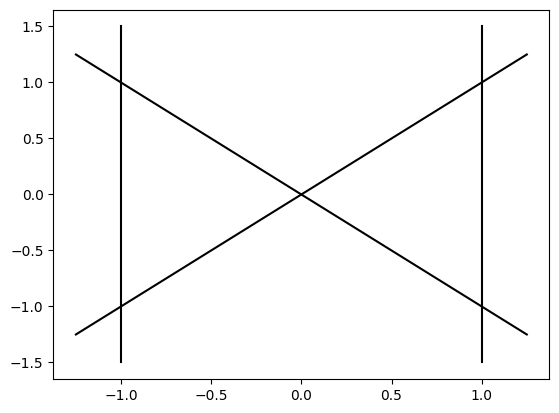

In [36]:
def plot_bowtie() -> None:
    plt.plot((1.25, -1.25),(1.25, -1.25),'k')
    plt.plot((1.25, -1.25),(-1.25,1.25),'k')
    plt.plot((-1, -1),(-1.5,1.5),'k')
    plt.plot((1,1),(-1.5,1.5),'k')

plot_bowtie()
plt.show()

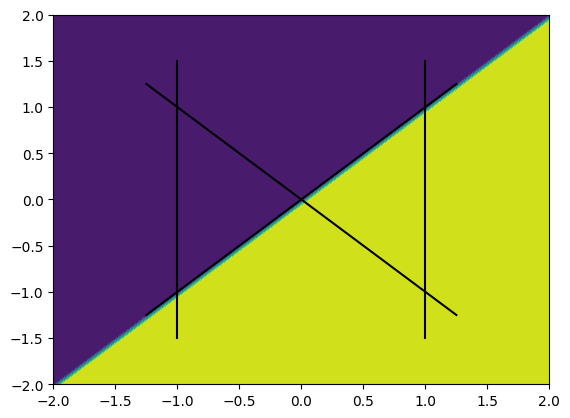

In [37]:
def plot_decision_boundary(grid_x: Tensor, grid_y, pred: Tensor) -> None:
    plot_bowtie()
    plt.contourf(grid_x, grid_y, pred.view(grid_x.shape))
    plt.show()

def activation(x: Tensor) -> Tensor:
    return torch.where(x > 0, 1., 0.)

def plot_decision_boundary_first_hidden(a: int, b: int, c: int) -> None:
    neuron_output = (
        activation(data @ torch.tensor([a, b, c], dtype=torch.float))
    )
    plot_decision_boundary(grid_x, grid_y, neuron_output)

plot_decision_boundary_first_hidden(0, 1, -1)


In [38]:
weights_1 = torch.tensor([
    [1,  0,  0], # bias neuron connected to the bias of the inputs
    [1, -1,  0],
    [1,  1,  0],
    [0,  1, -1],
    [0,  1,  1],
], dtype=torch.float).T
# Note: The weight matrix is transposed in the end. (5 x 3 --> 3 x 5)
# This gives more readability when entering your weights manually.
print(weights_1.shape)


torch.Size([3, 5])


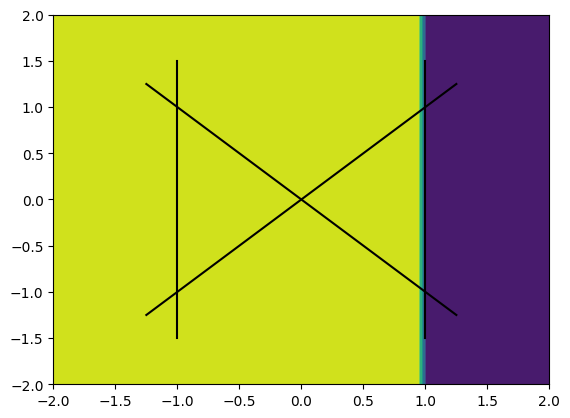

In [39]:
plot_decision_boundary_first_hidden(*weights_1[:, 1])

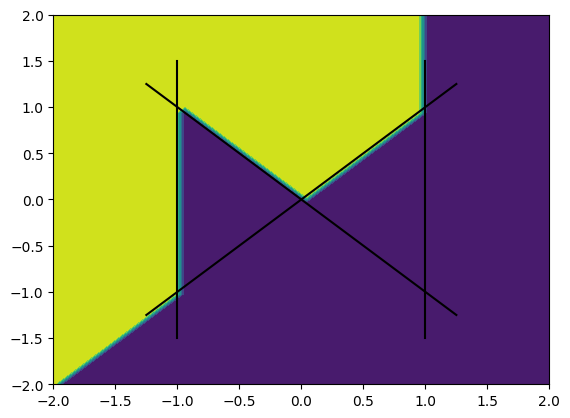

In [40]:
def plot_decision_boundary_second_hidden(
    a: int, b: int, c: int, d: int, e: int
) -> None:
    """Take 5 weights for one hidden neuron and plot resulting decision boundary."""
    neuron_output = (
        activation(hidden_1 @ torch.tensor([a, b, c, d, e], dtype=torch.float))
    )
    plot_decision_boundary(grid_x, grid_y, neuron_output)

plot_decision_boundary_second_hidden(-2, 3, -1, -3, 1)


In [41]:
weights_2 = torch.tensor([
    [ 1, 0, 0,  0,  0], # bias neuron connected to the bias of the inputs
    [-2, 1, 0,  1,  1],
    [-1, 1, 1, -1, -1],
], dtype=torch.float).T
# Note: The weight matrix is transposed in the end. (3 x 5 --> 5 x 3)
# This gives more readability when entering your weights manually.
print(weights_2.shape)


torch.Size([5, 3])


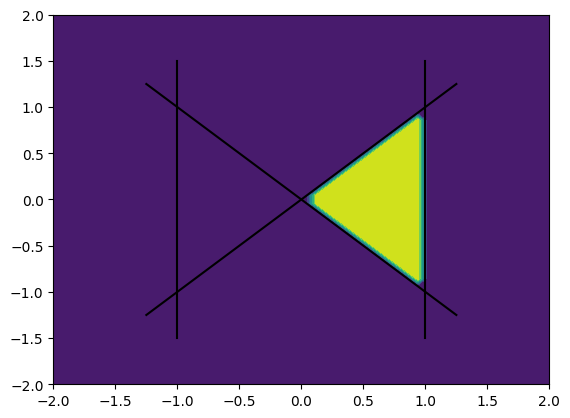

In [42]:
plot_decision_boundary_second_hidden(*weights_2[:, 1])

In [43]:
hidden_2 = (
    activation(hidden_1 @ weights_2)
)
# Make sure that the number of rows is not changed,
print(len(hidden_2) == len(data))
# that there are three columns,
print(hidden_2.shape[1] == 3)
# and that the values are between zero and one
print(float(torch.min(hidden_2)), float(torch.max(hidden_2)))


True
True
0.0 1.0


torch.Size([3])


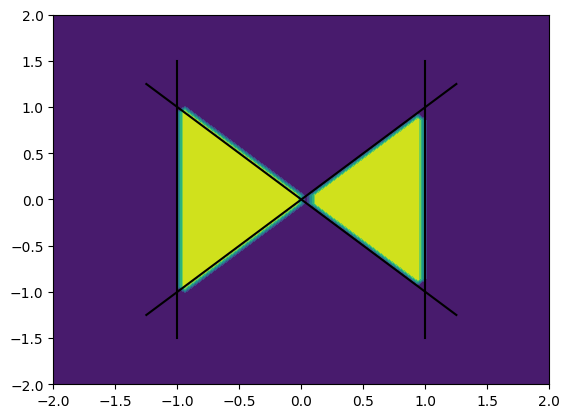

In [44]:
def plot_decision_boundary_output(a: int, b: int, c: int) -> None:
    """Take 3 weights for one output neuron and plot resulting decision boundary."""
    neuron_output = (
        hidden_2 @ torch.tensor([a, b, c], dtype=torch.float)
    )
    plot_decision_boundary(grid_x, grid_y, neuron_output)

weights_3 = torch.tensor([0, 1, 1], dtype=torch.float)
print(weights_3.shape)

plot_decision_boundary_output(*weights_3)


In [45]:
hidden_1 = activation(data @ weights_1)
hidden_2 = activation(hidden_1 @ weights_2)
output = hidden_2 @ weights_3

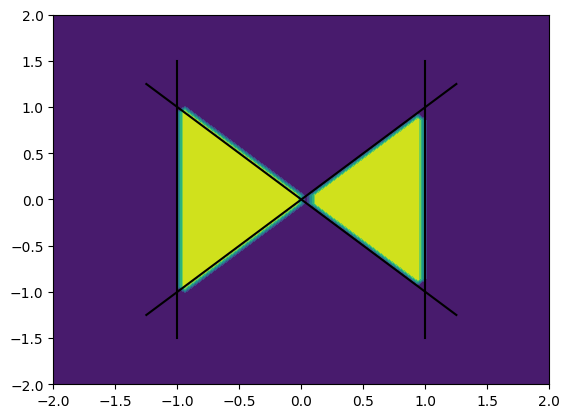

In [46]:
plot_decision_boundary(grid_x, grid_y, output)